In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Dice Loss
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

# Dice Metric
def dice_coefficient(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    y_pred_f = tf.cast(y_pred_f > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/lung_segmentation_baseline.h5",
    custom_objects={
        "dice_loss": dice_loss,
        "dice_coefficient": dice_coefficient
    }
)

print("Baseline model loaded successfully!")

Baseline model loaded successfully!


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient]
)

In [ ]:
def load_nodule(nodule_path):
    image_folder = os.path.join(nodule_path, "images")
    mask_folders = [os.path.join(nodule_path, m)
                    for m in os.listdir(nodule_path) if "mask" in m]

    images = []
    masks = []

    image_files = sorted(os.listdir(image_folder))

    for img_file in image_files:
        img_path = os.path.join(image_folder, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        images.append(img)

        combined_mask = np.zeros_like(img)

        for mask_folder in mask_folders:
            mask_path = os.path.join(mask_folder, img_file)
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                combined_mask = np.maximum(combined_mask, mask)

        masks.append(combined_mask)

    return np.array(images), np.array(masks)


def normalize_images(images):
    images = images.astype(np.float32) / 255.0
    return images


def resize_images(images, masks, size=(128,128)):
    resized_images = []
    resized_masks = []

    for img, mask in zip(images, masks):
        img_resized = cv2.resize(img, size)
        mask_resized = cv2.resize(mask, size)

        resized_images.append(img_resized)
        resized_masks.append(mask_resized)

    return np.array(resized_images), np.array(resized_masks)

In [ ]:
from google.colab import files
from tqdm import tqdm

uploaded = files.upload()  # shows upload progress UI

Saving archive (7).zip to archive (7).zip


In [ ]:
import zipfile
from tqdm import tqdm

zip_path = list(uploaded.keys())[0]
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

    for file in tqdm(file_list, desc="Extracting"):
        zip_ref.extract(file, extract_path)

print("Extraction complete!")

Extracting: 100%|██████████| 77740/77740 [00:12<00:00, 6465.78it/s] 

Extraction complete!


In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf

In [ ]:

dataset_path = "dataset/LIDC-IDRI-slices"  # change if needed

all_volumes = []
all_masks = []

for patient in os.listdir(dataset_path):
    patient_path = os.path.join(dataset_path, patient)

    if not os.path.isdir(patient_path):
        continue

    for nodule in os.listdir(patient_path):
        nodule_path = os.path.join(patient_path, nodule)

        if not os.path.isdir(nodule_path):
            continue

        try:
            images, masks = load_nodule(nodule_path)
            images = normalize_images(images)
            images, masks = resize_images(images, masks)

            all_volumes.append(images)
            all_masks.append(masks)

        except Exception as e:
            print("Skipping:", nodule_path, "Error:", e)

print("Total Nodules Loaded:", len(all_volumes))

Total Nodules Loaded: 2630


In [ ]:
TARGET_DEPTH = 8

def pad_depth(volume):
    depth = volume.shape[0]

    if depth >= TARGET_DEPTH:
        return volume[:TARGET_DEPTH]

    pad_before = (TARGET_DEPTH - depth) // 2
    pad_after = TARGET_DEPTH - depth - pad_before

    return np.pad(volume,
                  ((pad_before, pad_after), (0,0), (0,0)),
                  mode='constant')


X = np.array([pad_depth(v) for v in all_volumes])
Y = np.array([pad_depth(m) for m in all_masks])

# Add channel dimension
X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (2630, 8, 128, 128, 1)
Y shape: (2630, 8, 128, 128, 1)


In [ ]:
Y = (Y > 0).astype(np.float32)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
def compute_dice(y_true, y_pred):
    smooth = 1e-6
    y_true_f = y_true.flatten()
    y_pred_f = (y_pred > 0.5).astype(np.float32).flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2.*intersection + smooth) / (
        np.sum(y_true_f) + np.sum(y_pred_f) + smooth
    )

In [ ]:
def compute_dice(y_true, y_pred):
    smooth = 1e-6
    y_true_f = y_true.flatten()
    y_pred_f = (y_pred > 0.5).astype(np.float32).flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2.*intersection + smooth) / (
        np.sum(y_true_f) + np.sum(y_pred_f) + smooth
    )

# Predict
pred_baseline = model.predict(X_val)

dice_scores = [compute_dice(Y_val[i], pred_baseline[i]) for i in range(len(X_val))]
baseline_dice = np.mean(dice_scores)

print("Baseline Dice:", baseline_dice)

17/17 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step
Baseline Dice: 0.44161424


In [ ]:
def augment(volume, mask):

    if np.random.rand() > 0.5:
        volume = np.flip(volume, axis=2)
        mask = np.flip(mask, axis=2)

    if np.random.rand() > 0.5:
        volume = np.flip(volume, axis=1)
        mask = np.flip(mask, axis=1)

    if np.random.rand() > 0.5:
        noise = np.random.normal(0, 0.02, volume.shape)
        volume = volume + noise

    return volume, mask

In [ ]:
def data_generator(X, Y, batch_size=4):
    while True:
        idx = np.random.randint(0, len(X), batch_size)

        batch_X, batch_Y = [], []

        for i in idx:
            v, m = augment(X[i], Y[i])
            batch_X.append(v)
            batch_Y.append(m)

        yield np.array(batch_X), np.array(batch_Y)

In [ ]:
model_aug = model

In [ ]:
history_aug = model_aug.fit(
    data_generator(X_train, Y_train, batch_size=4),
    validation_data=(X_val, Y_val),
    steps_per_epoch=len(X_train)//4,
    epochs=20
)

Epoch 1/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 269s 512ms/step - dice_coefficient: 0.7108 - loss: 0.2993 - val_dice_coefficient: 0.6935 - val_loss: 0.3065
Epoch 2/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 268s 510ms/step - dice_coefficient: 0.7095 - loss: 0.2979 - val_dice_coefficient: 0.7239 - val_loss: 0.2745
Epoch 3/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 268s 510ms/step - dice_coefficient: 0.7172 - loss: 0.2893 - val_dice_coefficient: 0.7163 - val_loss: 0.2817
Epoch 4/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 268s 510ms/step - dice_coefficient: 0.7037 - loss: 0.3009 - val_dice_coefficient: 0.6987 - val_loss: 0.2940
Epoch 5/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 268s 510ms/step - dice_coefficient: 0.7245 - loss: 0.2793 - val_dice_coefficient: 0.6759 - val_loss: 0.3193
Epoch 6/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 268s 510ms/step - dice_coefficient: 0.7366 - loss: 0.2667 - val_dice_coefficient: 0.7228 - val_loss: 0.2704
Epoch 7/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 269s 511ms/step - dice_coefficient: 0.7292 - loss: 0.2734 - val_dice_coe

In [ ]:
pred_aug = model_aug.predict(X_val)

dice_scores_aug = [
    compute_dice(Y_val[i], pred_aug[i]) for i in range(len(X_val))
]

aug_dice = np.mean(dice_scores_aug)

print("Augmented Dice:", aug_dice)

17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 831ms/step
Augmented Dice: 0.65330327


In [ ]:
print("\n===== FINAL COMPARISON =====")
print(f"Baseline Dice : {baseline_dice:.4f}")
print(f"Augmented Dice: {aug_dice:.4f}")


===== FINAL COMPARISON =====
Baseline Dice : 0.4416
Augmented Dice: 0.6533


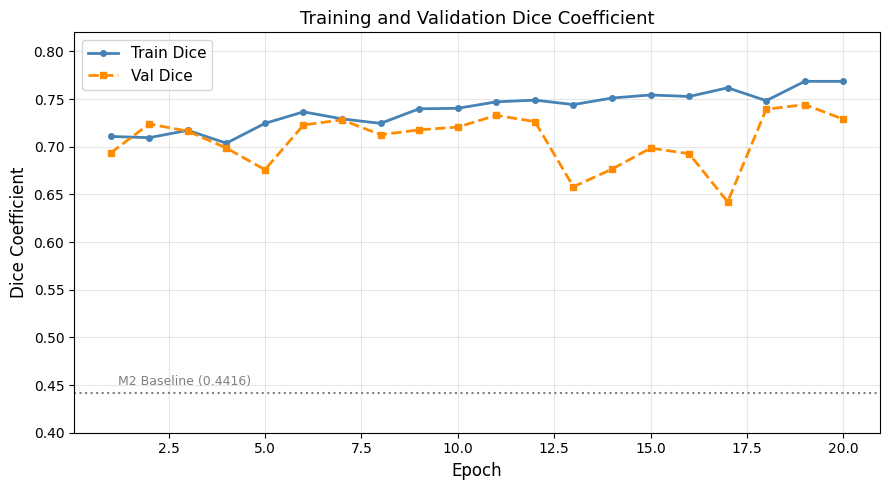

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 21))

train_dice = [0.7108, 0.7095, 0.7172, 0.7037, 0.7245, 0.7366, 0.7292, 0.7245,
              0.7398, 0.7403, 0.7471, 0.7489, 0.7442, 0.7511, 0.7543, 0.7527,
              0.7618, 0.7483, 0.7686, 0.7686]

val_dice   = [0.6935, 0.7239, 0.7163, 0.6987, 0.6759, 0.7228, 0.7282, 0.7126,
              0.7177, 0.7206, 0.7329, 0.7264, 0.6580, 0.6765, 0.6985, 0.6927,
              0.6422, 0.7393, 0.7442, 0.7288]

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_dice, label='Train Dice', color='steelblue', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, val_dice,   label='Val Dice',   color='darkorange', linewidth=2, marker='s', markersize=4, linestyle='--')
plt.axhline(y=0.4416, color='gray', linestyle=':', linewidth=1.5)
plt.text(1.2, 0.450, 'M2 Baseline (0.4416)', fontsize=9, color='gray')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Dice Coefficient', fontsize=12)
plt.title('Training and Validation Dice Coefficient', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(0.40, 0.82)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('image1.png', dpi=150)
plt.show()

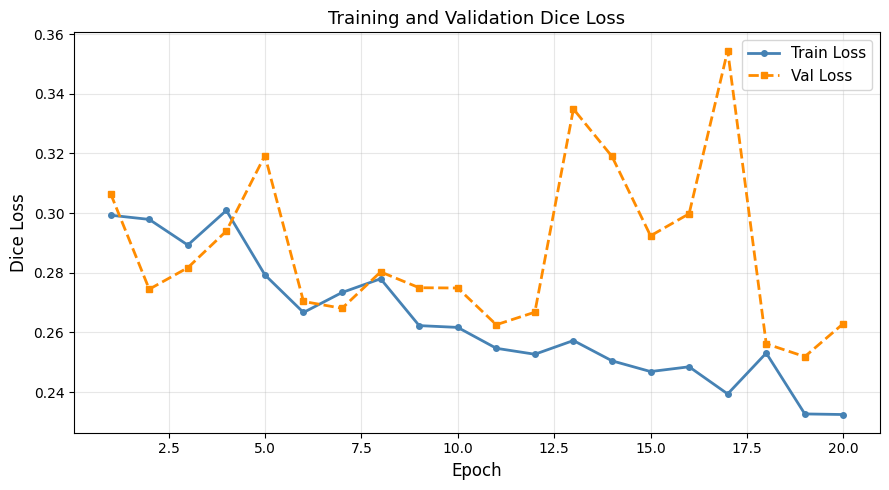

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 21))

train_loss = [0.2993, 0.2979, 0.2893, 0.3009, 0.2793, 0.2667, 0.2734, 0.2780,
              0.2623, 0.2617, 0.2547, 0.2527, 0.2573, 0.2505, 0.2469, 0.2485,
              0.2394, 0.2531, 0.2327, 0.2325]

val_loss   = [0.3065, 0.2745, 0.2817, 0.2940, 0.3193, 0.2704, 0.2681, 0.2803,
              0.2750, 0.2749, 0.2626, 0.2668, 0.3349, 0.3190, 0.2924, 0.2998,
              0.3545, 0.2562, 0.2519, 0.2630]

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_loss, label='Train Loss', color='steelblue', linewidth=2, marker='o', markersize=4)
plt.plot(epochs, val_loss,   label='Val Loss',   color='darkorange', linewidth=2, marker='s', markersize=4, linestyle='--')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Dice Loss', fontsize=12)
plt.title('Training and Validation Dice Loss', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('image2.png', dpi=150)
plt.show()

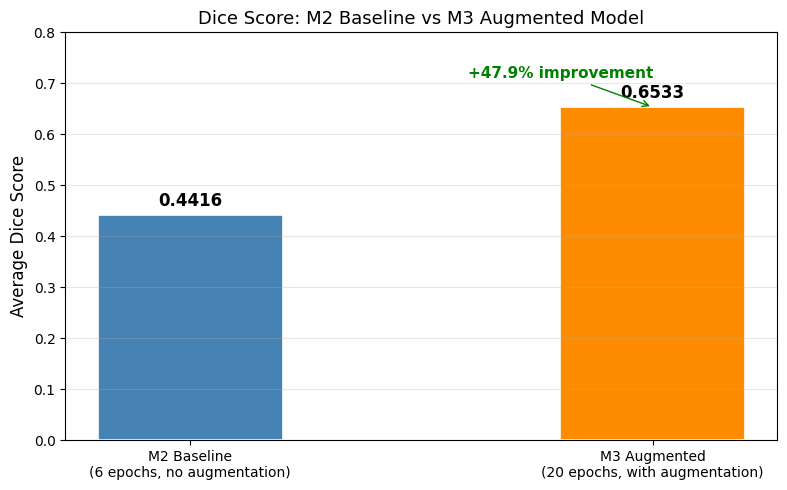

In [ ]:
import matplotlib.pyplot as plt

labels = ['M2 Baseline\n(6 epochs, no augmentation)', 'M3 Augmented\n(20 epochs, with augmentation)']
values = [0.4416, 0.6533]
colors = ['steelblue', 'darkorange']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors, width=0.4, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, 0.80)
plt.ylabel('Average Dice Score', fontsize=12)
plt.title('Dice Score: M2 Baseline vs M3 Augmented Model', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.annotate('+47.9% improvement',
             xy=(1, 0.6533), xytext=(0.6, 0.71),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=11, color='green', fontweight='bold')
plt.tight_layout()
plt.savefig('image3.png', dpi=150)
plt.show()